In [1]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 2: Load Dataset

# Dataset: Ames Housing (train.csv)
df = pd.read_csv("boston.csv")

print(df.shape)
df.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


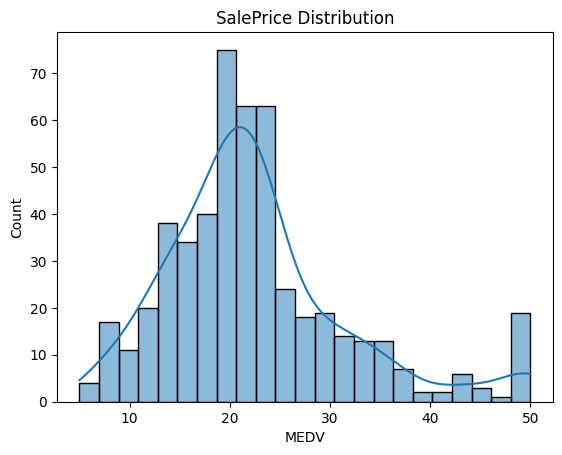

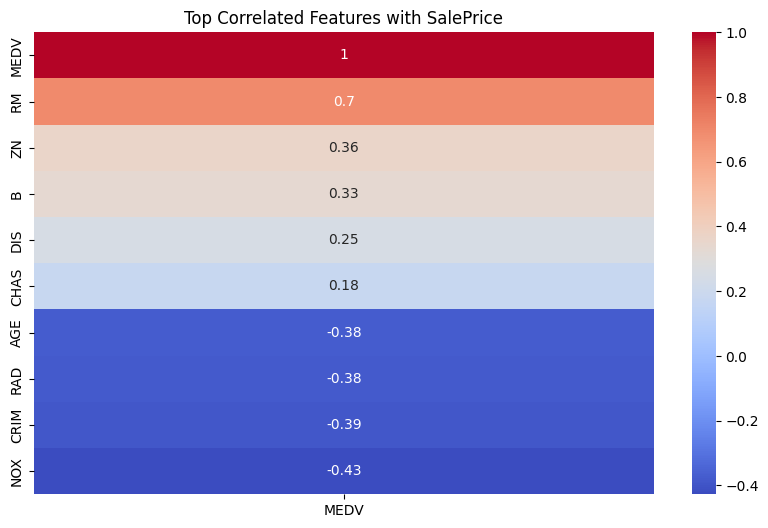

Series([], dtype: int64)


In [3]:
# Step 3: EDA (Exploratory Data Analysis)

# Target variable distribution
plt.figure()
sns.histplot(df['MEDV'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

# Correlation with target
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['MEDV']].sort_values(by='MEDV', ascending=False).head(10),
            annot=True, cmap='coolwarm')
plt.title("Top Correlated Features with SalePrice")
plt.show()

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(10))

In [4]:
# Step 4: Data Cleaning

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(506, 14)


In [5]:
# Step 5: Simple Linear Regression

# Independent Variable
X_simple = df[['RM']]
y = df['MEDV']

# Train-test split
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Model
slr = LinearRegression()
slr.fit(X_train_s, y_train)

# Prediction
y_pred_s = slr.predict(X_test_s)

# Evaluation
print("Simple Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_s))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_s)))

Simple Linear Regression
R2 Score: 0.3707569232254778
RMSE: 6.792994578778734


In [6]:
# Step 6: Multiple Linear Regression

X = df_encoded.drop('MEDV', axis=1)
y = df_encoded['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_m = mlr.predict(X_test)

print("Multiple Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_m))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_m)))

Multiple Linear Regression
R2 Score: 0.6687594935356317
RMSE: 4.928602182665339


In [7]:
# Step 7: Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Step 8: Ridge Regression

ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge Regression
R2 Score: 0.665967790505034
RMSE: 4.9493277947280285


In [9]:
# Step 9: Lasso Regression

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso Regression
R2 Score: 0.6687128230636585
RMSE: 4.928949380673859


In [10]:
# Step 10: Model Comparison

models = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_s),
        r2_score(y_test, y_pred_m),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_s)),
        np.sqrt(mean_squared_error(y_test, y_pred_m)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

models

,Model,R2 Score,RMSE
0,Simple Linear Regression,0.370757,6.792995
1,Multiple Linear Regression,0.668759,4.928602
2,Ridge Regression,0.665968,4.949328
3,Lasso Regression,0.668713,4.928949
